1. ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНЫЙ ПРОСМОТР ДАННЫХ

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import reuters

https://www.tensorflow.org/api_docs/python/tf/keras/datasets/reuters/load_data

In [ ]:
# TODO 1.1: Загрузите датасет Reuters
(x_train, y_train), (x_test, y_test) = reuters.load_data()

# TODO 1.2: Изучите структуру данных
print("Тип x_train:", type(x_train))
print("Длина x_train:", len(x_train))
print("Первая последовательность (первые 10 индексов):", x_train[0][:10])
print("Длина первой последовательности:", len(x_train[0]))

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
Тип x_train: <class 'numpy.ndarray'>
Длина x_train: 8982
Первая последовательность (первые 10 индексов): [1, 27595, 28842, 8, 43, 10, 447, 5, 25, 207]
Длина первой последовательности: 87


2. ПОДГОТОВКА СЛОВАРЯ И ДЕКОДИРОВАНИЕ

In [ ]:
# TODO 2.1: Загрузите словарь слов
word_index = reuters.get_word_index()
reverse_word_index = {value: key for (key, value) in word_index.items()}

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


In [ ]:
# TODO 2.2: Реализуйте функцию декодирования последовательности
def decode_sequence(sequence):
    return ' '.join([reverse_word_index.get(i-3, '?') for i in sequence])

first_article = decode_sequence(x_train[0])
print("\nПервая статья (первые 200 символов):", first_article[:200])


Первая статья (первые 200 символов): ? mcgrath rentcorp said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net shou


3. ПОДГОТОВКА ДАННЫХ ДЛЯ ГЕНЕРАЦИИ ТЕКСТА

In [ ]:
# TODO 3.1: Объедините первые 1000 статей в один текст
max_articles = 1000
max_articles_idx = x_train[:max_articles]
max_articles_texts = [decode_sequence(seq) for seq in max_articles_idx]
texts = ' '.join(max_articles_texts)

print(f"Общая длина текста (символов): {len(texts)}")
print("Пример текста:", texts[:500])

Общая длина текста (символов): 815340
Пример текста: ? mcgrath rentcorp said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3 ? generale de banque sa lt genb br and lt heller overseas corp of chicago have each taken 50 pct 


In [ ]:
# TODO 3.2: Создайте словари для преобразования символов в индексы и обратно
chars = sorted(list(set(texts)))
print(chars)

[' ', "'", '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [ ]:
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

vocab_size = len(chars)
print(f"Размер словаря (уникальных символов): {vocab_size}")

Размер словаря (уникальных символов): 39


In [ ]:
idx_to_char

{0: ' ',
 1: "'",
 2: '0',
 3: '1',
 4: '2',
 5: '3',
 6: '4',
 7: '5',
 8: '6',
 9: '7',
 10: '8',
 11: '9',
 12: '?',
 13: 'a',
 14: 'b',
 15: 'c',
 16: 'd',
 17: 'e',
 18: 'f',
 19: 'g',
 20: 'h',
 21: 'i',
 22: 'j',
 23: 'k',
 24: 'l',
 25: 'm',
 26: 'n',
 27: 'o',
 28: 'p',
 29: 'q',
 30: 'r',
 31: 's',
 32: 't',
 33: 'u',
 34: 'v',
 35: 'w',
 36: 'x',
 37: 'y',
 38: 'z'}

In [ ]:
# TODO 3.3: Преобразуйте текст в последовательность индексов
text_as_int = [char_to_idx[ch] for ch in texts]
texts[:10], text_as_int[:10]

('? mcgrath ', [12, 0, 25, 15, 19, 30, 13, 32, 20, 0])

In [ ]:
text_as_int = np.array(text_as_int)

text_as_int

array([12,  0, 25, ..., 30,  0,  5])

4. ФОРМИРОВАНИЕ ПРОМПТОВ И ОТВЕТОВ

In [ ]:
seq_length = 100

In [ ]:
# TODO 4.1: Реализуйте функцию create_sequences для создания обучающих примеров
def create_sequences(text_indices, seq_len):
    input_seq = []
    target_seq = []

    for i in range(len(text_indices)-seq_len):
        current_x_seq = text_indices[i:i+seq_len]
        input_seq.append(current_x_seq)

        current_y_seq = text_indices[i+seq_len]
        target_seq.append(current_y_seq)

    return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target_seq, dtype=torch.long)

input_seq, target_seq = create_sequences(text_as_int, seq_length)

/tmp/ipython-input-232/2203781802.py:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target_seq, dtype=torch.long)


In [ ]:
input_seq

tensor([[12,  0, 25,  ..., 17, 30,  0],
        [ 0, 25, 15,  ..., 30,  0, 31],
        [25, 15, 19,  ...,  0, 31, 20],
        ...,
        [26, 21, 26,  ..., 33, 32, 17],
        [21, 26, 17,  ..., 32, 17, 30],
        [26, 17,  0,  ..., 17, 30,  0]])

In [ ]:
target_seq

tensor([31, 20, 13,  ..., 30,  0,  5])

In [ ]:
print(f"Количество примеров: {len(input_seq)}")
print(f"Форма input_seq: {input_seq.shape}")
print(f"Форма target_seq: {target_seq.shape}")

Количество примеров: 815240
Форма input_seq: torch.Size([815240, 100])
Форма target_seq: torch.Size([815240])


In [ ]:
# TODO 4.2: Создайте DataLoader для пакетной обработки
batch_size = 32
dataset = torch.utils.data.TensorDataset(input_seq, target_seq)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
dataset

In [ ]:
dataloader

5. ОПРЕДЕЛЕНИЕ МОДЕЛИ LSTM

In [ ]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, num_layers=2, embedding_dim=64):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # TODO 5.1: Определите слои модели
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=self.num_layers,
            batch_first=True,
            dropout=0.2,
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        # TODO 5.2: Реализуйте forward pass
        # Шаг 1: Примените слой эмбеддинга
        embedded = self.embedding(x)

        # Шаг 2: Прямой проход через LSTM
        if hidden is None:
            lstm_out, hidden = self.lstm(embedded)
        else:
            lstm_out, hidden = self.lstm(embedded, hidden)

        # Шаг 3: Возьмите только последний выход LSTM
        lstm_out = lstm_out[:, -1, :]

        # Шаг 4: Примените полносвязный слой
        output = self.fc(lstm_out)

        return output, hidden

device = torch.device('cuda')

6. ОБУЧЕНИЕ МОДЕЛИ

In [ ]:
# Функция для генерации текста
def generate_text(model, seed_text, length=100, temperature=1.0):
    """Генерация текста на основе начальной последовательности."""
    model.eval()
    generated = seed_text

    # Преобразуем seed в индексы, фильтруя символы, которых нет в словаре
    seed_indices = []
    for ch in seed_text:
        if ch in char_to_idx:
            seed_indices.append(char_to_idx[ch])
        else:
            # Если символа нет в словаре, используем первый попавшийся символ
            seed_indices.append(0)

    if len(seed_indices) == 0:
        seed_indices = [0]  # На случай пустого seed

    with torch.no_grad():
        # Создаем начальное hidden state
        batch_size = 1
        h0 = torch.zeros(model.num_layers, batch_size, model.hidden_size).to(device)
        c0 = torch.zeros(model.num_layers, batch_size, model.hidden_size).to(device)
        hidden = (h0, c0)

        # "Прогреваем" модель на seed последовательности
        for i in range(len(seed_indices) - 1):
            input_tensor = torch.tensor([[seed_indices[i]]], dtype=torch.long).to(device)
            _, hidden = model(input_tensor, hidden)

        # Начинаем генерацию
        current_input = torch.tensor([[seed_indices[-1]]], dtype=torch.long).to(device)

        for _ in range(length):
            output, hidden = model(current_input, hidden)

            # Применяем temperature для управления случайностью
            output = output / temperature
            probabilities = torch.softmax(output, dim=-1)

            # Выбираем следующий символ на основе вероятностей
            next_char_idx = torch.multinomial(probabilities, 1).item()

            # Добавляем символ к сгенерированному тексту
            generated += idx_to_char[next_char_idx]

            # Обновляем вход для следующей итерации
            current_input = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)

    return generated

---

# ДОМАШНЕЕ ЗАДАНИЕ (дедлайн: 28 февраля, 23.59)

**Задача:** обучить модель с разными гиперпараметрами

1. Набор A: hidden_size=64, num_layers=1, learning_rate=0.01

2. Набор B: hidden_size=256, num_layers=2, learning_rate=0.001

3. Набор C: любой произвольный набор параметров hidden_size, num_layers, learning_rate, отличный от предложенных

Сравните:

- Скорость сходимости (график loss)
- Качество генерации (осмысленность текста)
- Время обучения

In [ ]:
EPOCHS = 4

In [ ]:
models_losses = []

for hs, nl, lr in zip([64, 256, 128], [1, 2, 3], [0.01, 0.001, 0.001]):
    # Инициализируйте модель
    model = CharLSTM(vocab_size=vocab_size, hidden_size=hs, num_layers=nl)
    model = model.to(device)
    print(f"\nМодель:\n{model}")

    # Определите функцию потерь и оптимизатор
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Тренировочный цикл
    train_losses = []

    print("\nНачало обучения...")
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        batch_count = len(dataloader)

        for batch_idx, (batch_input, batch_target) in enumerate(dataloader):
            # Перемещаем данные на GPU
            batch_input = batch_input.to(device)
            batch_target = batch_target.to(device)

            optimizer.zero_grad()

            # Прямой проход
            output, _ = model(batch_input)
            loss = criterion(output, batch_target)

            # Обратное распространение
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

            # Логгирование прогресса каждые 50 батчей
            if (batch_idx + 1) % 50 == 0:
                avg_batch_loss = loss.item()
                print(f'Эпоха [{epoch+1}/{EPOCHS}], Батч [{batch_idx+1}/{batch_count}], Потеря: {avg_batch_loss:.4f}')

        avg_loss = total_loss / len(dataloader)
        train_losses.append(avg_loss)

        # Генерация текста для мониторинга прогресса
        if (epoch + 1) % 2 == 0:
            # Используем seed текст, который точно есть в нашем словаре
            # Преобразуем к нижнему регистру, чтобы гарантировать наличие символов
            seed = "the company said"
            # Альтернативно: можно проверить, какие символы есть в словаре
            safe_seed = ''.join([ch for ch in seed if ch in char_to_idx])
            if len(safe_seed) > 0:
                generated = generate_text(model, safe_seed, length=50, temperature=0.8)
                print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
                print(f'Сгенерированный текст: "{generated}"')
            else:
                print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
                print('Не удалось сгенерировать текст: seed содержит неизвестные символы')
    models_losses.append(train_losses)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Выходные данные были обрезаны до нескольких последних строк (5000).
Эпоха [3/4], Батч [6200/25477], Потеря: 1.7711
Эпоха [3/4], Батч [6250/25477], Потеря: 1.5331
Эпоха [3/4], Батч [6300/25477], Потеря: 2.0904
Эпоха [3/4], Батч [6350/25477], Потеря: 1.7760
Эпоха [3/4], Батч [6400/25477], Потеря: 1.9673
Эпоха [3/4], Батч [6450/25477], Потеря: 2.1476
Эпоха [3/4], Батч [6500/25477], Потеря: 1.6109
Эпоха [3/4], Батч [6550/25477], Потеря: 2.1181
Эпоха [3/4], Батч [6600/25477], Потеря: 1.4736
Эпоха [3/4], Батч [6650/25477], Потеря: 1.8472
Эпоха [3/4], Батч [6700/25477], Потеря: 1.8314
Эпоха [3/4], Батч [6750/25477], Потеря: 1.6229
Эпоха [3/4], Батч [6800/25477], Потеря: 1.7751
Эпоха [3/4], Батч [6850/25477], Потеря: 1.6414
Эпоха [3/4], Батч [6900/25477], Потеря: 1.4842
Эпоха [3/4], Батч [6950/25477], Потеря: 1.7939
Эпоха [3/4], Батч [7000/25477], Потеря: 1.5691
Эпоха [3/4], Батч [7050/25477], Потеря: 2.3080
Эпоха [3/4], Батч [7100/25477], Потеря: 2.0414
Эпоха [3/4], Батч [7150/25477], Потеря:

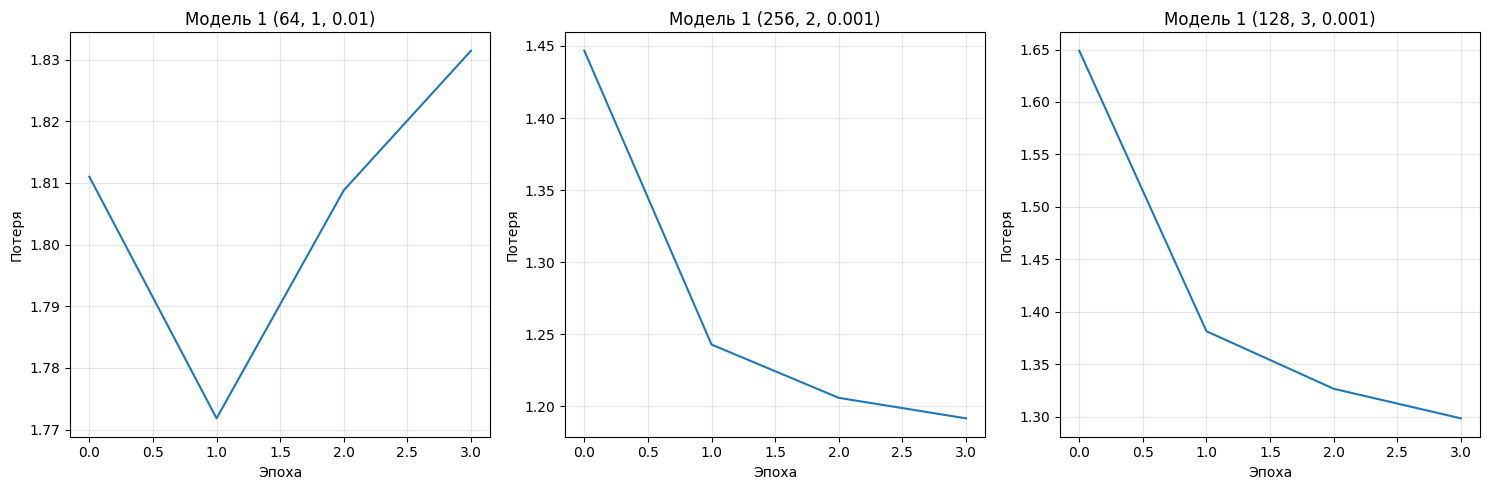

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Первый график
axes[0].plot(models_losses[0])
axes[0].set_title('Модель 1 (64, 1, 0.01)')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Потеря')
axes[0].grid(True, alpha=0.3)

axes[1].plot(models_losses[1])
axes[1].set_title('Модель 1 (256, 2, 0.001)')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Потеря')
axes[1].grid(True, alpha=0.3)

axes[2].plot(models_losses[2])
axes[2].set_title('Модель 1 (128, 3, 0.001)')
axes[2].set_xlabel('Эпоха')
axes[2].set_ylabel('Потеря')
axes[2].grid(True, alpha=0.3)

# Автоматически подгоняем расположение
plt.tight_layout()
plt.show()

1. У модели с learning_rate=0.01 потери после 2 эпохи растут. Это связано с недостаточно маленьким шагом (в отличие от 2 и 3 моделей).
2. Генерации моделей:
- the company said the fferer it the corpor to contorates at market
- the company said it said a share the producers also said even the
- the company said down total exchange of exploration said common st

Результат первой модели хуже, чем у других: появляются странные слова (fferer, corpor), слова не связаны грамматически и по смыслу.

У остальных моделей результат лучше, но появляются повторения "said", полной связности добиться не удалось, но связные отрывки увеличились

3. Средние ошибки (наилучший результат у второй модели, что можно объяснить наибольшим hidden_size и достаточно маленьким размером шага):
- 1.8314
- 1.1918
- 1.2987

4. Время обучения

Все три модели обучились примерно за полчаса (точное время, к сожалению, не засекала, а перезапускать код ради этого не хочется)
Наиболее долго обучалась вторая модель, так как у нее наибольший hidden_size
Время обучения первой и последней модели были меньше и почти не отличались

### **ВОПРОСЫ ДЛЯ РЕФЛЕКСИИ**

1.  Какие ключевые отличия вы заметили в подготовке данных для числового ряда (синусоида) и текста?

2.  Какой опыт работы с PyTorch (например, отладка, подбор параметров) оказался самым полезным?

1. С числовым рядом работать проще, так как для него нет необходимости кодирования и декодирования слов. В случае текста при подаче в модель и получении результатов необходимо превращать текст в числа и обратно.
2. Самым полезным мне показался общий процесс обучения, так как тут необходимо самостоятельно прописывать цикл обучения, благодаря чему становится более понятно, что происходит внутри модели.